In [1]:
import math 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import accuracy_score 
from skopt import BayesSearchCV 
from skopt.space import Integer 
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
data = pd.DataFrame(data = iris.data , columns=iris.feature_names)
data['target'] = iris.target 
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [3]:
X = data.iloc[:,0:data.shape[1]-1]
y = data.iloc[:,4]
print(X.shape)
print(y.shape)

(150, 4)
(150,)


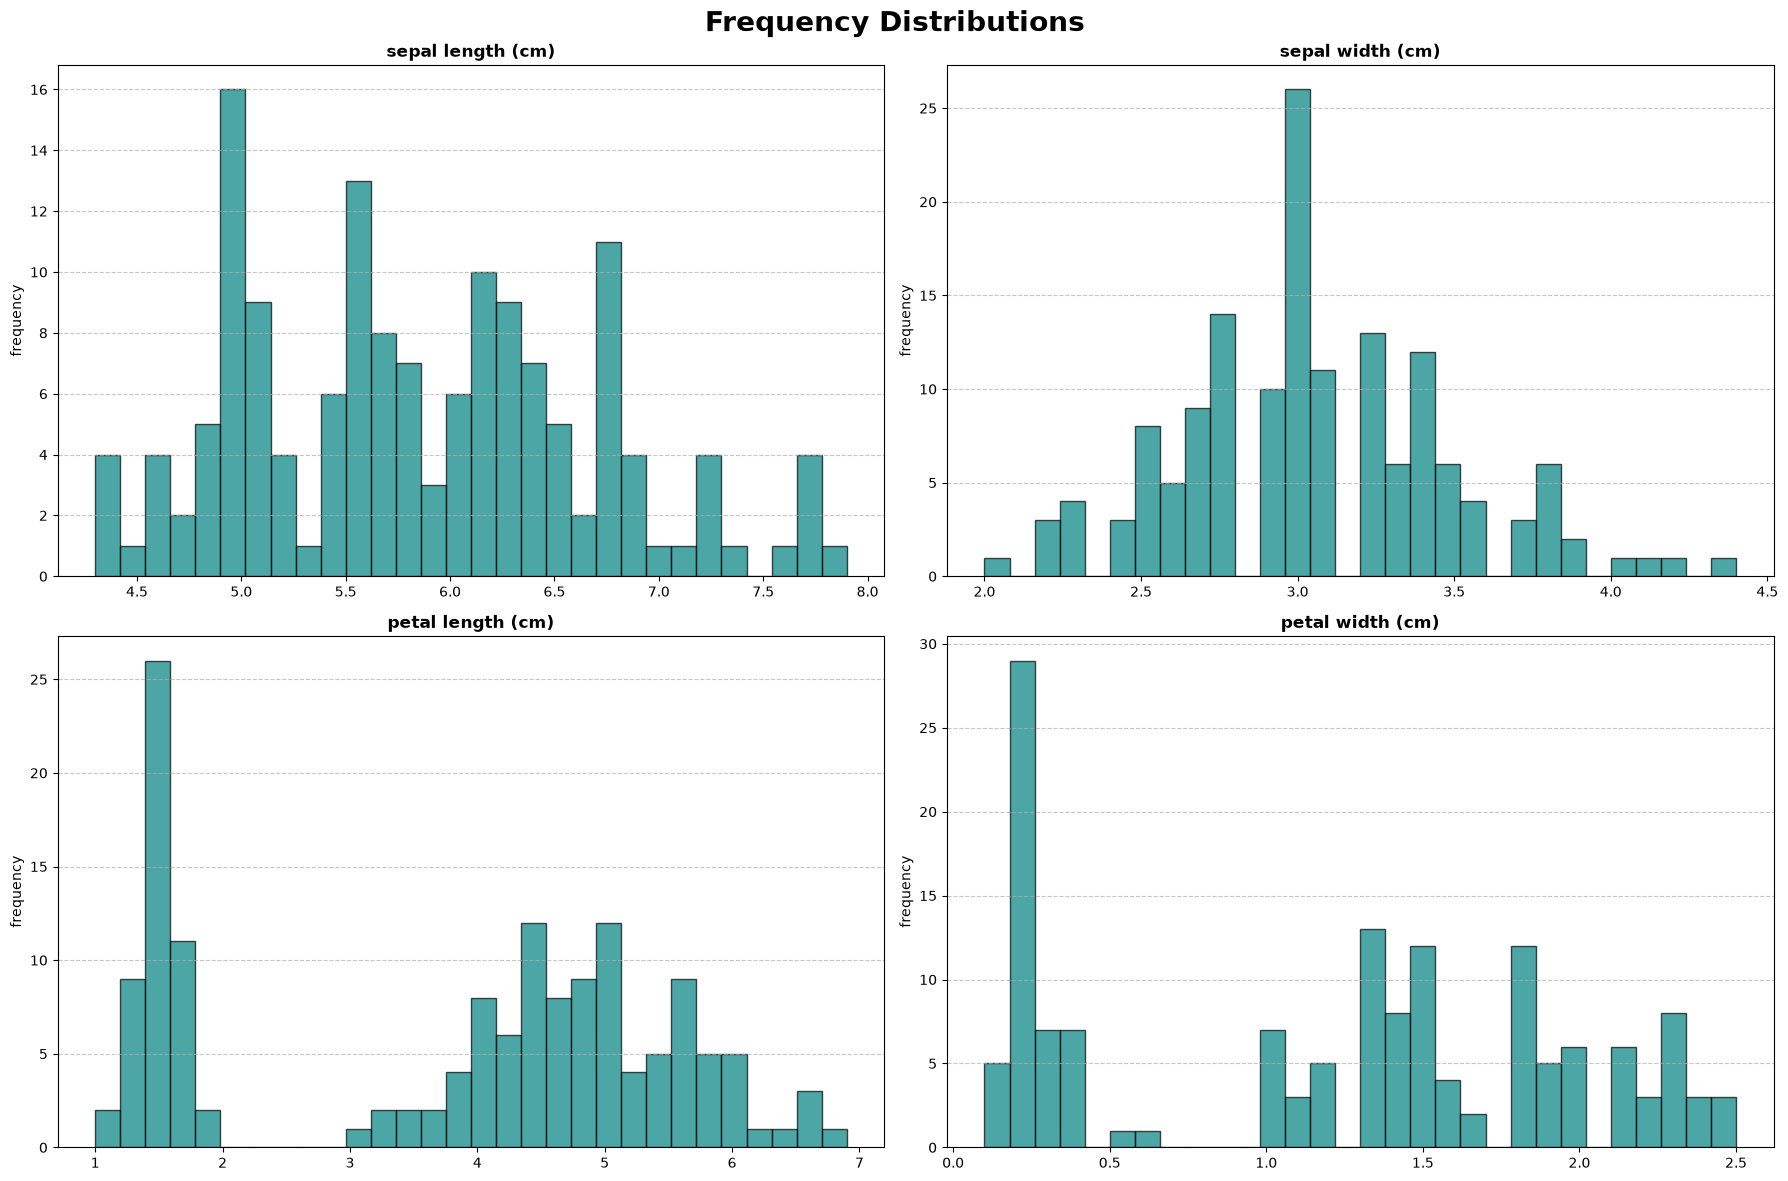

In [4]:
num_features = X.shape[1]
num_rows = math.ceil(num_features/2)
ax = X.hist(layout=(num_rows,2),figsize=(18,num_rows*6),bins=30,color = 'teal', edgecolor = 'black', alpha = 0.7)
for ax in ax.flatten():
    ax.set_title(ax.get_title(),fontsize = 12, fontweight = 'bold')
    ax.set_ylabel("frequency",fontsize = 10)
    ax.grid(axis = 'x', visible = False)
    ax.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.suptitle("Frequency Distributions", fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()
    

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X, y , test_size = 0.2 ,stratify = y , random_state = 42)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [6]:
from sklearn.model_selection import cross_validate

dtc = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state=42)
cv_score = cross_validate(
    estimator = dtc,
    X = X_train,
    y = y_train,
    cv = cv , 
    scoring = ['accuracy','precision_macro','f1_macro','recall_macro']
)
df = pd.DataFrame(cv_score)
print(df)

   fit_time  score_time  test_accuracy  test_precision_macro  test_f1_macro  \
0  0.010902    0.010038       0.958333              0.962963       0.958170   
1  0.003781    0.009357       0.958333              0.962963       0.958170   
2  0.003072    0.012948       0.958333              0.962963       0.958170   
3  0.002835    0.019612       0.958333              0.962963       0.958170   
4  0.002573    0.017819       0.916667              0.933333       0.915344   

   test_recall_macro  
0           0.958333  
1           0.958333  
2           0.958333  
3           0.958333  
4           0.916667  


In [7]:
print(df['test_accuracy'].mean())

0.95


In [13]:
#grid search optimization
param_grid = {
    "criterion":["gini","entropy","log_loss"],
    "max_depth":[None, 1,2],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[2,3],
    "max_features":[None , 'sqrt'],
    "splitter":["best","random"],
    "ccp_alpha":[0,0.1]
    
}
grid_search = GridSearchCV(
    estimator=dtc,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    refit = "f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0, 0.1], 'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 1, ...], 'max_features': [None, 'sqrt'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-

In [14]:
print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

{'ccp_alpha': 0, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'splitter': 'best'}
0.9665359477124185


In [15]:
from sklearn.metrics import accuracy_score

y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9333333333333333


In [16]:
param_dist = {
    "criterion":["gini","entropy","log_loss"],
    "max_depth":[None ,1,2],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[2,3],
    "max_features": [None, "sqrt", "log2"],
    "splitter":["best","random"],
    "ccp_alpha":[0,0.1]
}
random_search = RandomizedSearchCV(
    estimator = dtc,
    n_iter = 50,
    param_distributions = param_dist,
    cv = cv, 
    scoring = ['accuracy','precision_macro','f1_macro','recall_macro'],
    refit = 'f1_macro',
    error_score = 'raise',
    n_jobs = -1,
    verbose = 1
)
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'ccp_alpha': [0, 0.1], 'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 1, ...], 'max_features': [None, 'sqrt', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","['accuracy', 'precision_macro', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle

In [17]:
print(random_search.best_params_)
print(random_search.best_score_)

best_model = random_search.best_estimator_

{'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 2, 'criterion': 'gini', 'ccp_alpha': 0.1}
0.9665359477124185


In [18]:
results = pd.DataFrame(random_search.cv_results_)
print(results[
    [
        "mean_test_f1_macro",
        "mean_test_accuracy",
        "mean_test_precision_macro",
        "mean_test_recall_macro"
    ]
].head())

   mean_test_f1_macro  mean_test_accuracy  mean_test_precision_macro  \
0            0.700584            0.741667                   0.854994   
1            0.555556            0.666667                   0.500000   
2            0.941040            0.941667                   0.951111   
3            0.966536            0.966667                   0.970370   
4            0.549333            0.658333                   0.498039   

   mean_test_recall_macro  
0                0.741667  
1                0.666667  
2                0.941667  
3                0.966667  
4                0.658333  


In [19]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9333333333333333


In [21]:
from skopt.space import Categorical, Real
search_spaces = {
    "criterion":Categorical(["gini","entropy","log_loss"]),
    "max_depth": Categorical([None, 3, 5]),
    "min_samples_split":Integer(2,10),
    "min_samples_leaf":Integer(2,3),
    "max_features":Categorical([None , 'sqrt']),
    "splitter":Categorical(["best","random"]),
    "ccp_alpha":Integer(0,0.1)
}
bayes_search = BayesSearchCV(
    estimator = dtc,
    n_iter = 50,
    search_spaces = search_spaces,
    cv = cv, 
    scoring = ['accuracy','precision_macro','f1_macro','recall_macro'],
    refit = 'f1_macro',
    error_score = 'raise',
    n_jobs = -1,
    verbose = 1
)
bayes_search.fit(X_train,y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,DecisionTreeC...ndom_state=42)
,search_spaces,"{'ccp_alpha': Integer(low=0...m='normalize'), 'criterion': Categorical(c...), prior=None), 'max_depth': Categorical(c...), prior=None), 'max_features': Categorical(c...), prior=None), ...}"
,scoring,"['accuracy', 'precision_macro', ...]"
,n_jobs,-1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,optimizer_kwargs,None
,n_iter,50
,fit_params,None
,n_points,1


In [22]:
print(random_search.best_params_)
print(random_search.best_score_)

best_model = random_search.best_estimator_

{'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 2, 'criterion': 'gini', 'ccp_alpha': 0.1}
0.9665359477124185


In [23]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9333333333333333
